# Notebook 6 — 5-Fold Cross Validation Ensemble
Train 5 models and ensemble predictions for better DSC

In [1]:
import os
import numpy as np
import nibabel as nib
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch.cuda.amp import autocast, GradScaler
from tqdm import tqdm
import random
import time
import json
import psutil
import matplotlib.pyplot as plt

# ============================================================
# SETTINGS
# ============================================================
preprocessed_path = 'preprocessed'
save_dir_imgs     = os.path.join(preprocessed_path, 'imagesTr')
save_dir_lbls     = os.path.join(preprocessed_path, 'labelsTr')
checkpoint_dir    = 'checkpoints_5fold'
log_dir           = 'training_logs_5fold'
os.makedirs(checkpoint_dir, exist_ok=True)
os.makedirs(log_dir, exist_ok=True)
os.makedirs('visualization_outputs', exist_ok=True)

PATCH_SIZE      = (128, 128, 128)
PATCHES_PER_VOL = 2
BATCH_SIZE      = 2
NUM_EPOCHS      = 50
LR              = 1e-4
WEIGHT_DECAY    = 1e-5
NUM_FOLDS       = 5

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
set_seed(42)

print(f'Device  : {device}')
print(f'GPU     : {torch.cuda.get_device_name(0)}')
print(f'VRAM    : {torch.cuda.get_device_properties(0).total_memory/1024**3:.1f} GB')
print(f'RAM     : {psutil.virtual_memory().available/1024**3:.1f} GB available')
print(f'Epochs  : {NUM_EPOCHS} per fold')
print(f'Folds   : {NUM_FOLDS}')
print(f'Est.Time: ~{NUM_EPOCHS * NUM_FOLDS * 57 / 3600:.1f} hours')

Device  : cuda
GPU     : NVIDIA GeForce RTX 4060
VRAM    : 8.0 GB
RAM     : 2.4 GB available
Epochs  : 50 per fold
Folds   : 5
Est.Time: ~4.0 hours


## Model + Loss Definitions

In [2]:
# ============================================================
# MODEL
# ============================================================
class ConvBlock(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv3d(in_ch, out_ch, 3, padding=1, bias=False),
            nn.InstanceNorm3d(out_ch, affine=True),
            nn.LeakyReLU(0.01, inplace=True),
            nn.Conv3d(out_ch, out_ch, 3, padding=1, bias=False),
            nn.InstanceNorm3d(out_ch, affine=True),
            nn.LeakyReLU(0.01, inplace=True),
        )
    def forward(self, x):
        return self.block(x)

class EncoderBlock(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.conv = ConvBlock(in_ch, out_ch)
        self.down = nn.Conv3d(out_ch, out_ch, 2, stride=2, bias=False)
    def forward(self, x):
        skip = self.conv(x)
        return self.down(skip), skip

class DecoderBlock(nn.Module):
    def __init__(self, in_ch, skip_ch, out_ch):
        super().__init__()
        self.up   = nn.ConvTranspose3d(in_ch, out_ch, 2, stride=2)
        self.conv = ConvBlock(out_ch + skip_ch, out_ch)
    def forward(self, x, skip):
        return self.conv(torch.cat([self.up(x), skip], dim=1))

class nnUNet(nn.Module):
    def __init__(self, in_ch=1, out_ch=2, features=[32,64,128,256,320]):
        super().__init__()
        self.enc1       = EncoderBlock(in_ch,       features[0])
        self.enc2       = EncoderBlock(features[0], features[1])
        self.enc3       = EncoderBlock(features[1], features[2])
        self.enc4       = EncoderBlock(features[2], features[3])
        self.enc5       = EncoderBlock(features[3], features[4])
        self.bottleneck = ConvBlock(features[4], features[4])
        self.dec5       = DecoderBlock(features[4], features[4], features[3])
        self.dec4       = DecoderBlock(features[3], features[3], features[2])
        self.dec3       = DecoderBlock(features[2], features[2], features[1])
        self.dec2       = DecoderBlock(features[1], features[1], features[0])
        self.dec1       = DecoderBlock(features[0], features[0], features[0])
        self.out_conv   = nn.Conv3d(features[0], out_ch, 1)
        self.ds4        = nn.Conv3d(features[3], out_ch, 1)
        self.ds3        = nn.Conv3d(features[2], out_ch, 1)
        self.ds2        = nn.Conv3d(features[1], out_ch, 1)

    def forward(self, x):
        x1, s1 = self.enc1(x)
        x2, s2 = self.enc2(x1)
        x3, s3 = self.enc3(x2)
        x4, s4 = self.enc4(x3)
        x5, s5 = self.enc5(x4)
        b       = self.bottleneck(x5)
        d5      = self.dec5(b,  s5)
        d4      = self.dec4(d5, s4)
        d3      = self.dec3(d4, s3)
        d2      = self.dec2(d3, s2)
        d1      = self.dec1(d2, s1)
        out     = self.out_conv(d1)
        if self.training:
            return out, self.ds4(d5), self.ds3(d4), self.ds2(d3)
        return out

# ============================================================
# LOSSES
# ============================================================
class DiceLoss(nn.Module):
    def __init__(self, smooth=1e-5):
        super().__init__()
        self.smooth = smooth
    def forward(self, pred, target):
        pred   = torch.softmax(pred, dim=1)[:, 1]
        target = target.squeeze(1)
        inter  = (pred * target).sum(dim=(1,2,3))
        union  = pred.sum(dim=(1,2,3)) + target.sum(dim=(1,2,3))
        return 1 - ((2*inter + self.smooth) / (union + self.smooth)).mean()

class DiceCELoss(nn.Module):
    def __init__(self):
        super().__init__()
        self.dice = DiceLoss()
        self.ce   = nn.CrossEntropyLoss()
    def forward(self, pred, target):
        return self.dice(pred, target) + self.ce(pred, target.squeeze(1).long())

class DeepSupervisionLoss(nn.Module):
    def __init__(self):
        super().__init__()
        self.loss    = DiceCELoss()
        self.weights = [0.5, 0.25, 0.15, 0.10]
    def forward(self, outputs, target):
        total = 0
        for w, out in zip(self.weights, outputs):
            t = F.interpolate(target, size=out.shape[2:], mode='nearest') if out.shape != target.shape else target
            total += w * self.loss(out, t)
        return total

print('Model and loss defined ✅')

Model and loss defined ✅


## Dataset Functions

In [3]:
def augment_patch(image, label):
    for ax in range(3):
        if random.random() > 0.5:
            image = np.flip(image, axis=ax).copy()
            label = np.flip(label, axis=ax).copy()
    k = random.randint(0, 3)
    if k > 0:
        image = np.rot90(image, k=k, axes=(0,1)).copy()
        label = np.rot90(label, k=k, axes=(0,1)).copy()
    if random.random() > 0.5:
        image = image * random.uniform(0.9, 1.1)
    if random.random() > 0.5:
        image = image + random.uniform(-0.1, 0.1)
    if random.random() > 0.5:
        image = image + np.random.normal(0, 0.05, image.shape).astype(np.float32)
    return image, label

def pad_volume(img, lbl, patch_size):
    for ax, p in enumerate(patch_size):
        if img.shape[ax] < p:
            pad     = [(0,0),(0,0),(0,0)]
            pad[ax] = (0, p - img.shape[ax])
            img = np.pad(img, pad, mode='constant')
            lbl = np.pad(lbl, pad, mode='constant')
    return img, lbl

def extract_patch_cache(image_files, label_files,
                        img_dir, lbl_dir,
                        patch_size=(128,128,128),
                        patches_per_volume=2):
    px, py, pz  = patch_size
    cached_imgs = []
    cached_lbls = []
    for fname_img, fname_lbl in tqdm(zip(image_files, label_files),
                                      total=len(image_files), desc='Caching'):
        img = nib.load(os.path.join(img_dir, fname_img)).get_fdata().astype(np.float32)
        lbl = nib.load(os.path.join(lbl_dir, fname_lbl)).get_fdata().astype(np.float32)
        img, lbl = pad_volume(img, lbl, patch_size)
        tumor_coords = np.argwhere(lbl == 1)
        if len(tumor_coords) == 0:
            continue
        idxs = np.random.choice(len(tumor_coords),
                                 size=min(patches_per_volume, len(tumor_coords)),
                                 replace=False)
        for i in idxs:
            cx, cy, cz = tumor_coords[i]
            xs = int(np.clip(cx - px//2, 0, img.shape[0] - px))
            ys = int(np.clip(cy - py//2, 0, img.shape[1] - py))
            zs = int(np.clip(cz - pz//2, 0, img.shape[2] - pz))
            cached_imgs.append(img[xs:xs+px, ys:ys+py, zs:zs+pz].copy())
            cached_lbls.append(lbl[xs:xs+px, ys:ys+py, zs:zs+pz].copy())
    return cached_imgs, cached_lbls

class CachedDataset(Dataset):
    def __init__(self, cached_imgs, cached_lbls, augment=True):
        self.imgs    = cached_imgs
        self.lbls    = cached_lbls
        self.augment = augment
    def __len__(self):
        return len(self.imgs)
    def __getitem__(self, idx):
        img = self.imgs[idx].copy()
        lbl = self.lbls[idx].copy()
        if self.augment:
            img, lbl = augment_patch(img, lbl)
        return torch.from_numpy(img).float().unsqueeze(0), \
               torch.from_numpy(lbl).float().unsqueeze(0)

print('Dataset functions defined ✅')

Dataset functions defined ✅


## Create 5 Folds

In [4]:
# Load all file lists
all_images = sorted([f for f in os.listdir(save_dir_imgs)
                     if f.endswith('.nii.gz') and not f.startswith('.')])
all_labels = sorted([f for f in os.listdir(save_dir_lbls)
                     if f.endswith('.nii.gz') and not f.startswith('.')])

# Shuffle with fixed seed
combined = list(zip(all_images, all_labels))
random.shuffle(combined)
all_imgs_s, all_lbls_s = zip(*combined)
all_imgs_s = list(all_imgs_s)
all_lbls_s = list(all_lbls_s)

# Create 5 folds
fold_size = len(all_imgs_s) // NUM_FOLDS
folds     = []
for i in range(NUM_FOLDS):
    start = i * fold_size
    end   = start + fold_size if i < NUM_FOLDS - 1 else len(all_imgs_s)
    folds.append({
        'val_imgs'  : all_imgs_s[start:end],
        'val_lbls'  : all_lbls_s[start:end],
        'train_imgs': all_imgs_s[:start] + all_imgs_s[end:],
        'train_lbls': all_lbls_s[:start] + all_lbls_s[end:],
    })

print(f'Total cases : {len(all_imgs_s)}')
print(f'Folds       : {NUM_FOLDS}')
for i, fold in enumerate(folds):
    print(f'  Fold {i+1}  — Train: {len(fold["train_imgs"])} | Val: {len(fold["val_imgs"])}')

Total cases : 126
Folds       : 5
  Fold 1  — Train: 101 | Val: 25
  Fold 2  — Train: 101 | Val: 25
  Fold 3  — Train: 101 | Val: 25
  Fold 4  — Train: 101 | Val: 25
  Fold 5  — Train: 100 | Val: 26


## Training Functions

In [6]:
def compute_dsc(pred, target, smooth=1e-5):
    pred   = (torch.softmax(pred, dim=1)[:, 1] > 0.5).float()
    target = target.squeeze(1)
    inter  = (pred * target).sum(dim=(1,2,3))
    union  = pred.sum(dim=(1,2,3)) + target.sum(dim=(1,2,3))
    return ((2*inter + smooth) / (union + smooth)).mean().item()

def train_one_epoch(model, loader, optimizer, criterion, scaler, device):
    model.train()
    total_loss = 0
    total_dsc  = 0
    for img, lbl in loader:
        img = img.to(device, non_blocking=True)
        lbl = lbl.to(device, non_blocking=True)
        optimizer.zero_grad()
        with torch.cuda.amp.autocast():
            outputs = model(img)
            loss    = criterion(outputs, lbl)
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()
        with torch.no_grad():
            total_dsc += compute_dsc(outputs[0], lbl)
        total_loss += loss.item()
    return total_loss / len(loader), total_dsc / len(loader)

def validate(model, loader, criterion, device):
    model.eval()
    total_loss = 0
    total_dsc  = 0
    with torch.no_grad():
        for img, lbl in loader:
            img  = img.to(device, non_blocking=True)
            lbl  = lbl.to(device, non_blocking=True)
            with torch.cuda.amp.autocast():
                out  = model(img)
                loss = criterion([out], lbl)
            total_loss += loss.item()
            total_dsc  += compute_dsc(out, lbl)
    return total_loss / len(loader), total_dsc / len(loader)

print('Training functions defined ✅')

Training functions defined ✅


## 5-Fold Training Loop

In [7]:
all_fold_histories = []
all_fold_best_dsc  = []
total_start        = time.time()

for fold_idx, fold in enumerate(folds):
    print(f'\n{"="*70}')
    print(f'FOLD {fold_idx+1}/{NUM_FOLDS} — Train: {len(fold["train_imgs"])} | Val: {len(fold["val_imgs"])}')
    print(f'={"="*70}')

    # Cache patches for this fold
    print('Caching training patches...')
    train_cache_imgs, train_cache_lbls = extract_patch_cache(
        fold['train_imgs'], fold['train_lbls'],
        save_dir_imgs, save_dir_lbls,
        patch_size=PATCH_SIZE, patches_per_volume=PATCHES_PER_VOL
    )
    print('Caching validation patches...')
    val_cache_imgs, val_cache_lbls = extract_patch_cache(
        fold['val_imgs'], fold['val_lbls'],
        save_dir_imgs, save_dir_lbls,
        patch_size=PATCH_SIZE, patches_per_volume=1
    )

    # Datasets and loaders
    train_dataset = CachedDataset(train_cache_imgs, train_cache_lbls, augment=True)
    val_dataset   = CachedDataset(val_cache_imgs,   val_cache_lbls,   augment=False)
    train_loader  = DataLoader(train_dataset, batch_size=BATCH_SIZE,
                                shuffle=True,  num_workers=0, pin_memory=True)
    val_loader    = DataLoader(val_dataset,   batch_size=1,
                                shuffle=False, num_workers=0, pin_memory=True)

    print(f'Train patches: {len(train_dataset)} | Val patches: {len(val_dataset)}')
    print(f'Train batches: {len(train_loader)}  | Val batches: {len(val_loader)}')

    # Fresh model for each fold
    model     = nnUNet(in_ch=1, out_ch=2).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='min', factor=0.5, patience=8, min_lr=1e-6
    )
    criterion = DeepSupervisionLoss()
    scaler    = GradScaler(init_scale=2.**16)   # ← FIXED

    best_val_dsc = 0.0
    history      = {'train_loss':[], 'val_loss':[], 'train_dsc':[], 'val_dsc':[], 'lr':[]}

    for epoch in range(1, NUM_EPOCHS + 1):
        start = time.time()

        train_loss, train_dsc = train_one_epoch(model, train_loader, optimizer, criterion, scaler, device)
        val_loss,   val_dsc   = validate(model, val_loader, criterion, device)

        scheduler.step(val_loss)
        current_lr = optimizer.param_groups[0]['lr']
        elapsed    = time.time() - start

        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        history['train_dsc'].append(train_dsc)
        history['val_dsc'].append(val_dsc)
        history['lr'].append(current_lr)

        print(f'  Fold {fold_idx+1} Epoch [{epoch:02d}/{NUM_EPOCHS}] '
              f'| Train Loss: {train_loss:.4f} DSC: {train_dsc:.4f} '
              f'| Val Loss: {val_loss:.4f} DSC: {val_dsc:.4f} '
              f'| LR: {current_lr:.6f} '
              f'| Time: {elapsed:.0f}s')

        # Save best model for this fold
        if val_dsc > best_val_dsc:
            best_val_dsc = val_dsc
            torch.save({
                'epoch'               : epoch,
                'model_state_dict'    : model.state_dict(),
                'optimizer_state_dict': optimizer.state_dict(),
                'val_dsc'             : val_dsc,
                'val_loss'            : val_loss,
                'fold'                : fold_idx + 1,
            }, os.path.join(checkpoint_dir, f'best_model_fold{fold_idx+1}.pth'))
            print(f'     ✅ Fold {fold_idx+1} best saved! Val DSC: {best_val_dsc:.4f}')

    # Save fold history
    all_fold_histories.append(history)
    all_fold_best_dsc.append(best_val_dsc)

    with open(os.path.join(log_dir, f'history_fold{fold_idx+1}.json'), 'w') as f:
        json.dump(history, f)

    print(f'\nFold {fold_idx+1} Complete — Best Val DSC: {best_val_dsc:.4f}')

    # Free memory
    del model, optimizer, scheduler, criterion, scaler
    del train_cache_imgs, train_cache_lbls, val_cache_imgs, val_cache_lbls
    del train_dataset, val_dataset, train_loader, val_loader
    torch.cuda.empty_cache()

# ============================================================
# FINAL SUMMARY
# ============================================================
total_time = time.time() - total_start
print(f'\n{"="*70}')
print(f'5-FOLD TRAINING COMPLETE')
print(f'={"="*70}')
for i, dsc in enumerate(all_fold_best_dsc):
    print(f'  Fold {i+1} Best Val DSC: {dsc:.4f}')
print(f'  Mean DSC          : {np.mean(all_fold_best_dsc):.4f}')
print(f'  Std DSC           : {np.std(all_fold_best_dsc):.4f}')
print(f'  Paper DSC         : 0.5600')
print(f'  Improvement       : {np.mean(all_fold_best_dsc) - 0.56:+.4f}')
print(f'  Total Time        : {total_time/3600:.1f} hours')
print(f'={"="*70}')


FOLD 1/5 — Train: 101 | Val: 25
Caching training patches...


Caching: 100%|███████████████████████████████████████████████████████████████████████| 101/101 [04:21<00:00,  2.59s/it]


Caching validation patches...


Caching: 100%|█████████████████████████████████████████████████████████████████████████| 25/25 [00:57<00:00,  2.32s/it]


Train patches: 202 | Val patches: 25
Train batches: 101  | Val batches: 25
  Fold 1 Epoch [01/50] | Train Loss: 1.3893 DSC: 0.0097 | Val Loss: 0.6865 DSC: 0.0001 | LR: 0.000100 | Time: 62s
     ✅ Fold 1 best saved! Val DSC: 0.0001
  Fold 1 Epoch [02/50] | Train Loss: 1.1985 DSC: 0.0987 | Val Loss: 0.6454 DSC: 0.3124 | LR: 0.000100 | Time: 59s
     ✅ Fold 1 best saved! Val DSC: 0.3124
  Fold 1 Epoch [03/50] | Train Loss: 1.1065 DSC: 0.3563 | Val Loss: 0.6116 DSC: 0.4494 | LR: 0.000100 | Time: 58s
     ✅ Fold 1 best saved! Val DSC: 0.4494
  Fold 1 Epoch [04/50] | Train Loss: 1.0401 DSC: 0.3931 | Val Loss: 0.5835 DSC: 0.4283 | LR: 0.000100 | Time: 57s
  Fold 1 Epoch [05/50] | Train Loss: 0.9842 DSC: 0.4059 | Val Loss: 0.5675 DSC: 0.4202 | LR: 0.000100 | Time: 56s
  Fold 1 Epoch [06/50] | Train Loss: 0.9362 DSC: 0.4290 | Val Loss: 0.5391 DSC: 0.3752 | LR: 0.000100 | Time: 57s
  Fold 1 Epoch [07/50] | Train Loss: 0.8957 DSC: 0.4400 | Val Loss: 0.5124 DSC: 0.5010 | LR: 0.000100 | Time: 56s
 

...

Train patches: 202 | Val patches: 25
Train batches: 101  | Val batches: 25
  Fold 4 Epoch [01/50] | Train Loss: 1.3927 DSC: 0.0173 | Val Loss: 0.6880 DSC: 0.0001 | LR: 0.000100 | Time: 57s
     ✅ Fold 4 best saved! Val DSC: 0.0001
  Fold 4 Epoch [02/50] | Train Loss: 1.1907 DSC: 0.0107 | Val Loss: 0.6450 DSC: 0.2724 | LR: 0.000100 | Time: 57s
     ✅ Fold 4 best saved! Val DSC: 0.2724
  Fold 4 Epoch [03/50] | Train Loss: 1.1101 DSC: 0.3342 | Val Loss: 0.6059 DSC: 0.4431 | LR: 0.000100 | Time: 58s
     ✅ Fold 4 best saved! Val DSC: 0.4431
  Fold 4 Epoch [04/50] | Train Loss: 1.0469 DSC: 0.3612 | Val Loss: 0.5797 DSC: 0.4668 | LR: 0.000100 | Time: 56s
     ✅ Fold 4 best saved! Val DSC: 0.4668
  Fold 4 Epoch [05/50] | Train Loss: 0.9945 DSC: 0.3866 | Val Loss: 0.5533 DSC: 0.4632 | LR: 0.000100 | Time: 57s
  Fold 4 Epoch [06/50] | Train Loss: 0.9548 DSC: 0.4070 | Val Loss: 0.5291 DSC: 0.4834 | LR: 0.000100 | Time: 57s
     ✅ Fold 4 best saved! Val DSC: 0.4834
  Fold 4 Epoch [07/50] | Train 

Caching: 100%|███████████████████████████████████████████████████████████████████████| 100/100 [04:07<00:00,  2.48s/it]


Caching validation patches...


Caching: 100%|█████████████████████████████████████████████████████████████████████████| 26/26 [01:08<00:00,  2.65s/it]


Train patches: 200 | Val patches: 26
Train batches: 100  | Val batches: 26
  Fold 5 Epoch [01/50] | Train Loss: 1.3664 DSC: 0.0145 | Val Loss: 0.7094 DSC: 0.0000 | LR: 0.000100 | Time: 56s
     ✅ Fold 5 best saved! Val DSC: 0.0000
  Fold 5 Epoch [02/50] | Train Loss: 1.1753 DSC: 0.2144 | Val Loss: 0.6700 DSC: 0.2632 | LR: 0.000100 | Time: 56s
     ✅ Fold 5 best saved! Val DSC: 0.2632
  Fold 5 Epoch [03/50] | Train Loss: 1.0913 DSC: 0.3854 | Val Loss: 0.6330 DSC: 0.3298 | LR: 0.000100 | Time: 56s
     ✅ Fold 5 best saved! Val DSC: 0.3298
  Fold 5 Epoch [04/50] | Train Loss: 1.0165 DSC: 0.4232 | Val Loss: 0.6066 DSC: 0.3676 | LR: 0.000100 | Time: 55s
     ✅ Fold 5 best saved! Val DSC: 0.3676
  Fold 5 Epoch [05/50] | Train Loss: 0.9584 DSC: 0.4503 | Val Loss: 0.5827 DSC: 0.3893 | LR: 0.000100 | Time: 56s
     ✅ Fold 5 best saved! Val DSC: 0.3893
  Fold 5 Epoch [06/50] | Train Loss: 0.9160 DSC: 0.4510 | Val Loss: 0.5587 DSC: 0.4240 | LR: 0.000100 | Time: 56s
     ✅ Fold 5 best saved! Val D

## Plot All Fold Training Curves

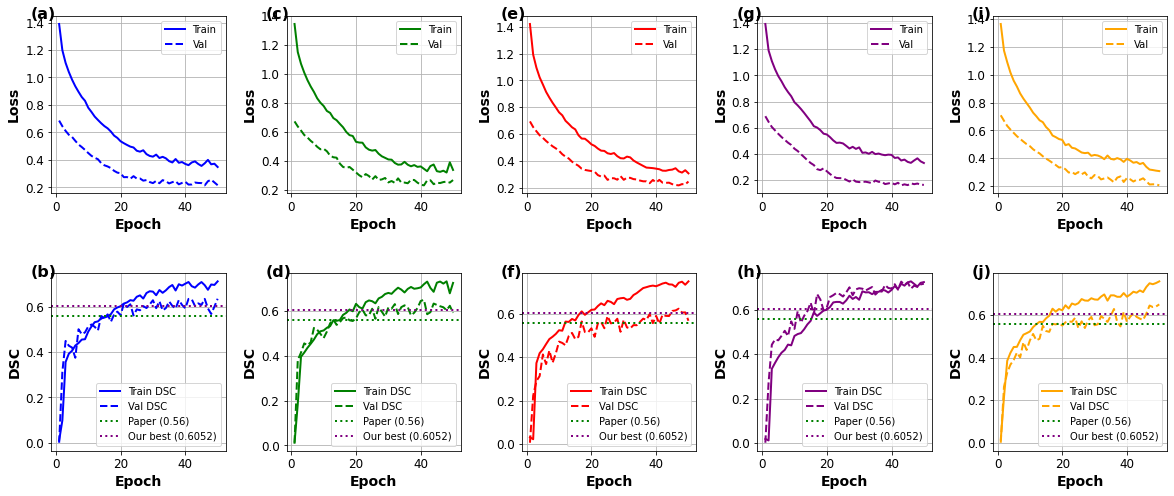

Saved → visualization_outputs/5fold_training_curves.png  (600 DPI PNG)


In [8]:
os.makedirs('visualization_outputs', exist_ok=True)

# ── Font settings ──────────────────────────────────────────
LABEL_SIZE  = 14
TICK_SIZE   = 12
LEGEND_SIZE = 10
PANEL_SIZE  = 16
LINE_WIDTH  = 2.0
PANEL_LABELS = ['(a)','(b)','(c)','(d)','(e)',
                '(f)','(g)','(h)','(i)','(j)']

colors = ['blue', 'green', 'red', 'purple', 'orange']

fig, axes = plt.subplots(2, NUM_FOLDS, figsize=(20, 8))
plt.subplots_adjust(hspace=0.45, wspace=0.35)

panel_idx = 0
for i, history in enumerate(all_fold_histories):
    epochs = range(1, len(history['train_loss']) + 1)

    # ── Loss row ───────────────────────────────────────────
    axes[0, i].plot(epochs, history['train_loss'], color=colors[i],
                    label='Train', linewidth=LINE_WIDTH)
    axes[0, i].plot(epochs, history['val_loss'],   color=colors[i],
                    linestyle='--', label='Val', linewidth=LINE_WIDTH)
    axes[0, i].set_xlabel('Epoch', fontsize=LABEL_SIZE, fontweight='bold')
    axes[0, i].set_ylabel('Loss',  fontsize=LABEL_SIZE, fontweight='bold')
    axes[0, i].tick_params(axis='both', labelsize=TICK_SIZE)
    axes[0, i].legend(fontsize=LEGEND_SIZE)
    axes[0, i].grid(True)
    axes[0, i].text(-0.12, 1.05, PANEL_LABELS[panel_idx],
                    transform=axes[0, i].transAxes,
                    fontsize=PANEL_SIZE, fontweight='bold', va='top', ha='left')
    panel_idx += 1

    # ── DSC row ────────────────────────────────────────────
    axes[1, i].plot(epochs, history['train_dsc'], color=colors[i],
                    label='Train DSC', linewidth=LINE_WIDTH)
    axes[1, i].plot(epochs, history['val_dsc'],   color=colors[i],
                    linestyle='--', label='Val DSC', linewidth=LINE_WIDTH)
    axes[1, i].axhline(y=0.56,   color='green',  linestyle=':',
                       linewidth=LINE_WIDTH, label='Paper (0.56)')
    axes[1, i].axhline(y=0.6052, color='purple', linestyle=':',
                       linewidth=LINE_WIDTH, label='Our best (0.6052)')
    axes[1, i].set_xlabel('Epoch', fontsize=LABEL_SIZE, fontweight='bold')
    axes[1, i].set_ylabel('DSC',   fontsize=LABEL_SIZE, fontweight='bold')
    axes[1, i].tick_params(axis='both', labelsize=TICK_SIZE)
    axes[1, i].legend(fontsize=LEGEND_SIZE)
    axes[1, i].grid(True)
    axes[1, i].text(-0.12, 1.05, PANEL_LABELS[panel_idx],
                    transform=axes[1, i].transAxes,
                    fontsize=PANEL_SIZE, fontweight='bold', va='top', ha='left')
    panel_idx += 1

# ── Save ───────────────────────────────────────────────────
plt.savefig('visualization_outputs/5fold_training_curves.png',
            bbox_inches='tight', dpi=600, format='png')
plt.show()
print('Saved → visualization_outputs/5fold_training_curves.png  (600 DPI PNG)')

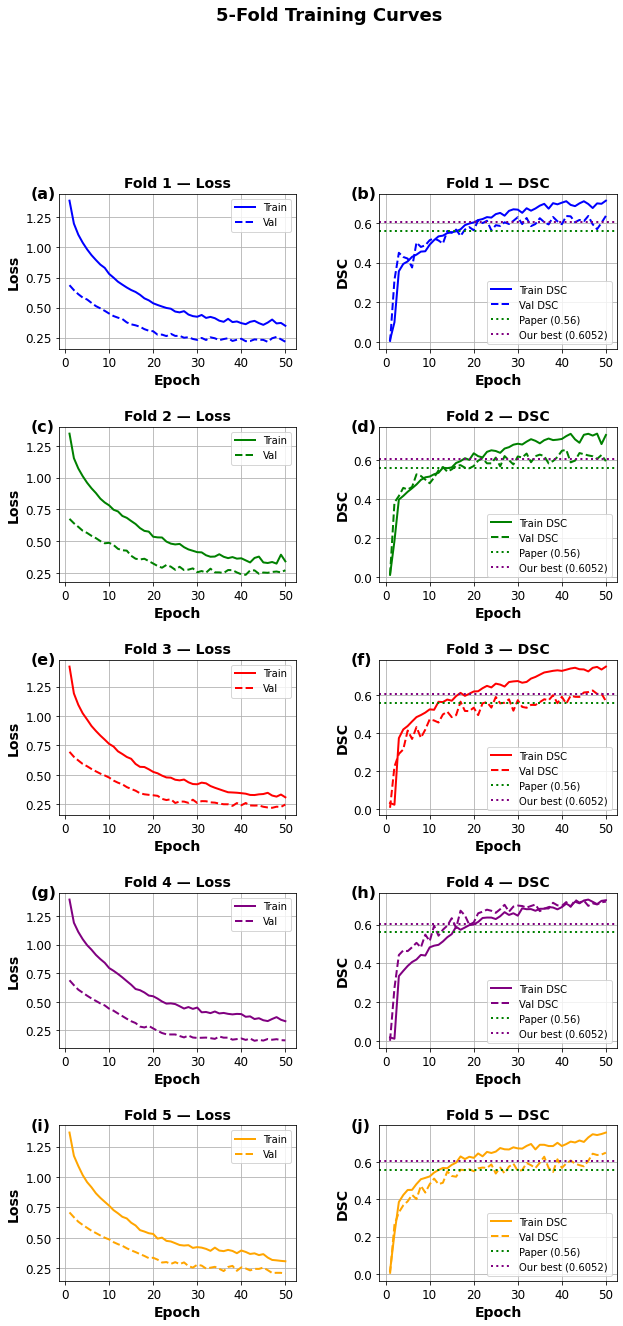

Saved → visualization_outputs/5fold_training_curves.png  (600 DPI PNG)


In [17]:
os.makedirs('visualization_outputs', exist_ok=True)

LABEL_SIZE   = 14
TICK_SIZE    = 12
LEGEND_SIZE  = 10
PANEL_SIZE   = 16
LINE_WIDTH   = 2.0
PANEL_LABELS = ['(a)','(b)','(c)','(d)','(e)',
                '(f)','(g)','(h)','(i)','(j)']
colors = ['blue', 'green', 'red', 'purple', 'orange']

# ← changed: NUM_FOLDS rows, 2 columns (Loss | DSC)
fig, axes = plt.subplots(NUM_FOLDS, 2, figsize=(10, NUM_FOLDS * 4))
plt.subplots_adjust(hspace=0.5, wspace=0.35)

panel_idx = 0
for i, history in enumerate(all_fold_histories):
    epochs = range(1, len(history['train_loss']) + 1)

    # ── Loss column (col 0) ────────────────────────────────
    axes[i, 0].plot(epochs, history['train_loss'], color=colors[i],
                    label='Train', linewidth=LINE_WIDTH)
    axes[i, 0].plot(epochs, history['val_loss'],   color=colors[i],
                    linestyle='--', label='Val', linewidth=LINE_WIDTH)
    axes[i, 0].set_xlabel('Epoch', fontsize=LABEL_SIZE, fontweight='bold')
    axes[i, 0].set_ylabel('Loss',  fontsize=LABEL_SIZE, fontweight='bold')
    axes[i, 0].set_title(f'Fold {i+1} — Loss', fontsize=LABEL_SIZE, fontweight='bold')
    axes[i, 0].tick_params(axis='both', labelsize=TICK_SIZE)
    axes[i, 0].legend(fontsize=LEGEND_SIZE)
    axes[i, 0].grid(True)
    axes[i, 0].text(-0.12, 1.05, PANEL_LABELS[panel_idx],
                    transform=axes[i, 0].transAxes,
                    fontsize=PANEL_SIZE, fontweight='bold', va='top', ha='left')
    panel_idx += 1

    # ── DSC column (col 1) ─────────────────────────────────
    axes[i, 1].plot(epochs, history['train_dsc'], color=colors[i],
                    label='Train DSC', linewidth=LINE_WIDTH)
    axes[i, 1].plot(epochs, history['val_dsc'],   color=colors[i],
                    linestyle='--', label='Val DSC', linewidth=LINE_WIDTH)
    axes[i, 1].axhline(y=0.56,   color='green',  linestyle=':',
                       linewidth=LINE_WIDTH, label='Paper (0.56)')
    axes[i, 1].axhline(y=0.6052, color='purple', linestyle=':',
                       linewidth=LINE_WIDTH, label='Our best (0.6052)')
    axes[i, 1].set_xlabel('Epoch', fontsize=LABEL_SIZE, fontweight='bold')
    axes[i, 1].set_ylabel('DSC',   fontsize=LABEL_SIZE, fontweight='bold')
    axes[i, 1].set_title(f'Fold {i+1} — DSC', fontsize=LABEL_SIZE, fontweight='bold')
    axes[i, 1].tick_params(axis='both', labelsize=TICK_SIZE)
    axes[i, 1].legend(fontsize=LEGEND_SIZE)
    axes[i, 1].grid(True)
    axes[i, 1].text(-0.12, 1.05, PANEL_LABELS[panel_idx],
                    transform=axes[i, 1].transAxes,
                    fontsize=PANEL_SIZE, fontweight='bold', va='top', ha='left')
    panel_idx += 1

plt.suptitle('5-Fold Training Curves', fontsize=18, fontweight='bold', y=1.01)
plt.savefig('visualization_outputs/5fold_training_curves.png',
            bbox_inches='tight', dpi=600, format='png')
plt.show()
print('Saved → visualization_outputs/5fold_training_curves.png  (600 DPI PNG)')

## Ensemble Evaluation — Average Predictions of 5 Models

In [9]:
def ensemble_predict(models, img_tensor, device):
    """
    Average softmax probabilities from all 5 models
    """
    all_probs = []
    for model in models:
        model.eval()
        with torch.no_grad():
            with torch.cuda.amp.autocast():
                out   = model(img_tensor)
                probs = torch.softmax(out, dim=1)[:, 1]  # tumor prob
        all_probs.append(probs)
    avg_probs = torch.stack(all_probs).mean(dim=0)
    return (avg_probs > 0.5).float()

# Load all 5 best models
print('Loading all 5 fold models...')
models = []
for fold_idx in range(NUM_FOLDS):
    ckpt_path = os.path.join(checkpoint_dir, f'best_model_fold{fold_idx+1}.pth')
    model     = nnUNet(in_ch=1, out_ch=2).to(device)
    ckpt      = torch.load(ckpt_path, map_location=device)
    model.load_state_dict(ckpt['model_state_dict'])
    model.eval()
    models.append(model)
    print(f'  Fold {fold_idx+1} loaded — Best Val DSC: {ckpt["val_dsc"]:.4f}')

# Evaluate ensemble on all validation patches
print('\nEvaluating ensemble...')

# Use all cached val patches from last fold for quick test
print('Caching all validation patches for ensemble eval...')
all_val_imgs, all_val_lbls = extract_patch_cache(
    all_imgs_s, all_lbls_s,
    save_dir_imgs, save_dir_lbls,
    patch_size=PATCH_SIZE, patches_per_volume=1
)

val_dataset_full = CachedDataset(all_val_imgs, all_val_lbls, augment=False)
val_loader_full  = DataLoader(val_dataset_full, batch_size=1, shuffle=False,
                               num_workers=0, pin_memory=True)

ensemble_dsc = 0
smooth       = 1e-5

with torch.no_grad():
    for img, lbl in tqdm(val_loader_full, desc='Ensemble eval'):
        img  = img.to(device)
        lbl  = lbl.to(device).squeeze(1)
        pred = ensemble_predict(models, img, device)
        inter = (pred * lbl).sum(dim=(1,2,3))
        union = pred.sum(dim=(1,2,3)) + lbl.sum(dim=(1,2,3))
        ensemble_dsc += ((2*inter + smooth) / (union + smooth)).mean().item()

ensemble_dsc /= len(val_loader_full)

print(f'\n{"="*50}')
print(f'ENSEMBLE RESULTS')
print(f'{"="*50}')
print(f'Individual fold mean DSC : {np.mean(all_fold_best_dsc):.4f}')
print(f'Ensemble DSC             : {ensemble_dsc:.4f}')
print(f'Paper DSC                : 0.5600')
print(f'Improvement over paper   : {ensemble_dsc - 0.56:+.4f}')
print(f'Improvement over single  : {ensemble_dsc - 0.6052:+.4f}')
print(f'{"="*50}')

Loading all 5 fold models...
  Fold 1 loaded — Best Val DSC: 0.6356
  Fold 2 loaded — Best Val DSC: 0.6514
  Fold 3 loaded — Best Val DSC: 0.6240
  Fold 4 loaded — Best Val DSC: 0.7284
  Fold 5 loaded — Best Val DSC: 0.6508

Evaluating ensemble...
Caching all validation patches for ensemble eval...


Ensemble eval: 100%|█████████████████████████████████████████████████████████████████| 126/126 [00:41<00:00,  3.05it/s]


ENSEMBLE RESULTS
Individual fold mean DSC : 0.6580
Ensemble DSC             : 0.7174
Paper DSC                : 0.5600
Improvement over paper   : +0.1574
Improvement over single  : +0.1122


## ACTUAL vs PREDICTED VISUALIZATION

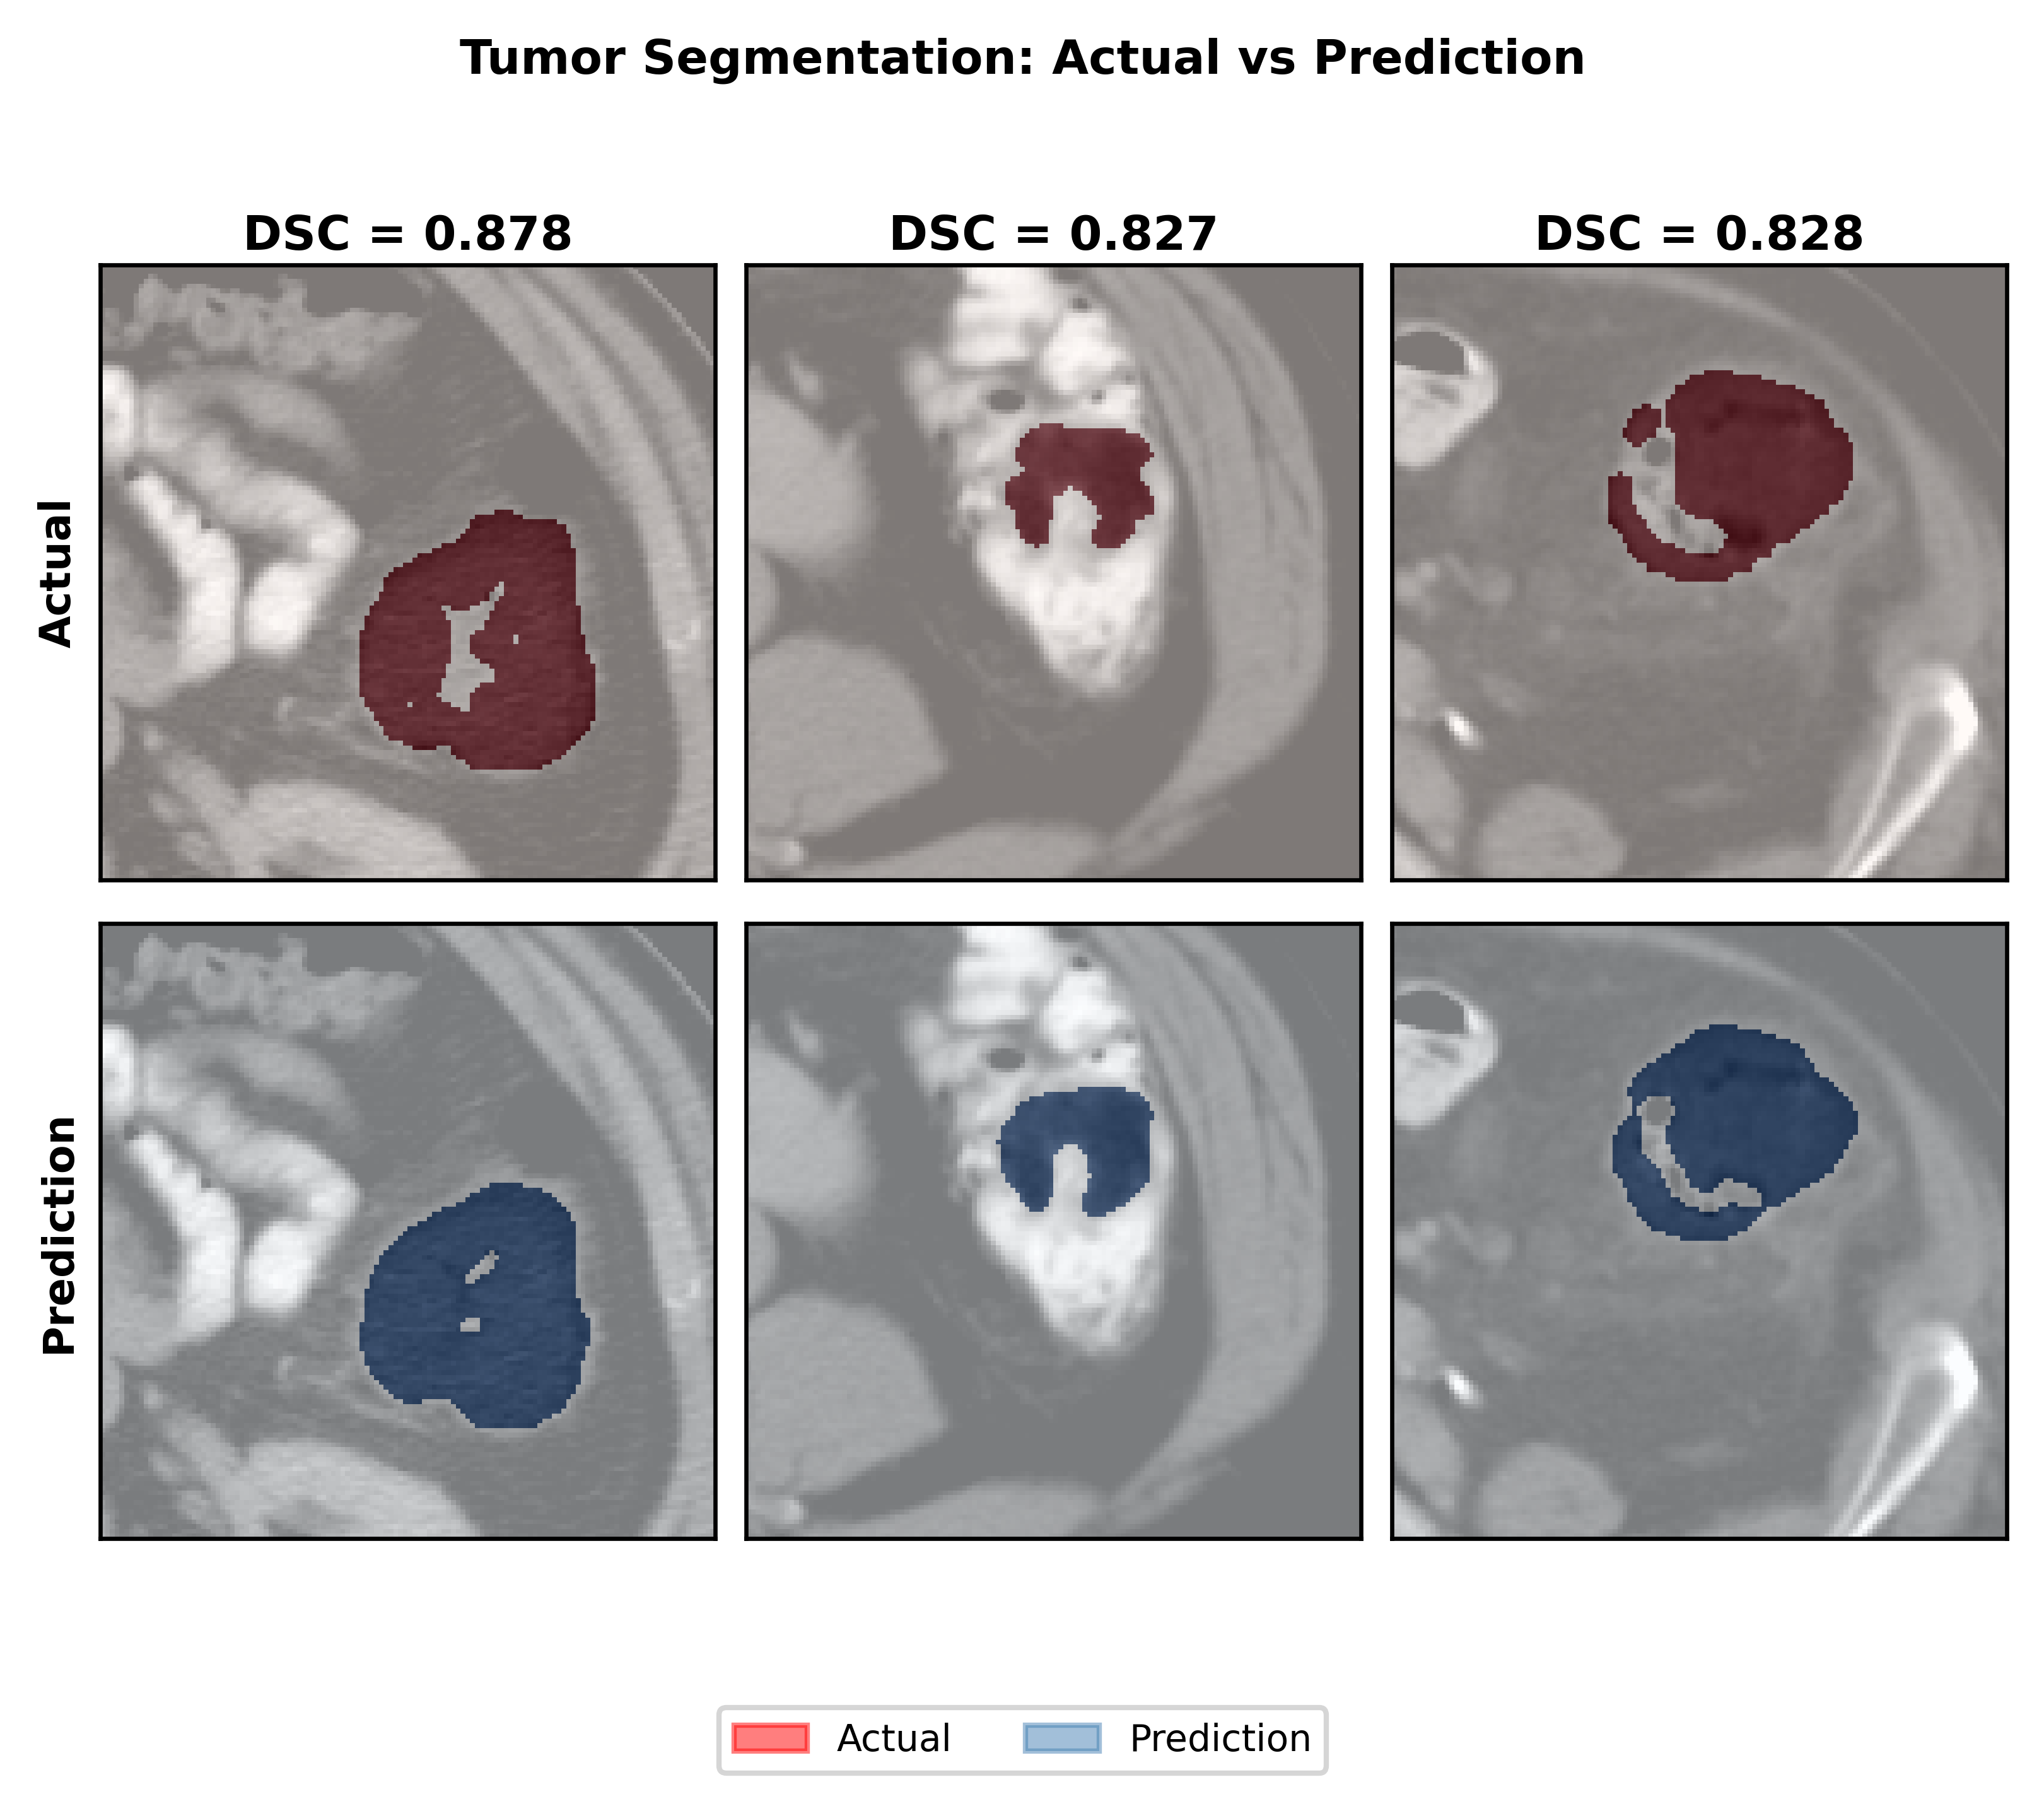

Saved → visualization_outputs/paper_figure.png


In [16]:
import matplotlib.patches as mpatches

NUM_SAMPLES = 3
fig, axes = plt.subplots(2, NUM_SAMPLES, figsize=(6.5, 4.5), dpi=600)
plt.subplots_adjust(hspace=0.05, wspace=0.05)

axes[0, 0].set_ylabel('Actual',     fontsize=8, fontweight='bold')
axes[1, 0].set_ylabel('Prediction', fontsize=8, fontweight='bold')

indices = np.random.choice(len(all_val_imgs), size=NUM_SAMPLES, replace=False)

for col, idx in enumerate(indices):
    img  = all_val_imgs[idx]
    lbl  = all_val_lbls[idx]

    img_tensor = torch.from_numpy(img).float().unsqueeze(0).unsqueeze(0).to(device)
    with torch.no_grad():
        pred = ensemble_predict(models, img_tensor, device)
    pred = pred.squeeze().cpu().numpy()

    best_slice = int(np.argmax(lbl.sum(axis=(0, 1))))
    img_2d  = img[:, :, best_slice]
    lbl_2d  = lbl[:, :, best_slice]
    pred_2d = pred[:, :, best_slice]

    inter = (pred * lbl).sum()
    union = pred.sum() + lbl.sum()
    dsc   = (2 * inter + 1e-5) / (union + 1e-5)

    axes[0, col].imshow(img_2d.T, cmap='gray', origin='lower')
    axes[0, col].imshow(lbl_2d.T, cmap='Reds', origin='lower', alpha=0.5)
    axes[0, col].set_title(f'DSC = {dsc:.3f}', fontsize=9, fontweight='bold', pad=3)  # ← bold

    axes[1, col].imshow(img_2d.T,  cmap='gray',  origin='lower')
    axes[1, col].imshow(pred_2d.T, cmap='Blues', origin='lower', alpha=0.5)

    for row in range(2):
        axes[row, col].set_xticks([])
        axes[row, col].set_yticks([])

gt_p   = mpatches.Patch(color='red',       alpha=0.5, label='Actual')
pred_p = mpatches.Patch(color='steelblue', alpha=0.5, label='Prediction')
fig.legend(handles=[gt_p, pred_p], loc='lower center',
           ncol=2, fontsize=7, bbox_to_anchor=(0.5, -0.02), frameon=True)

plt.suptitle('Tumor Segmentation: Actual vs Prediction',
             fontsize=9, fontweight='bold', y=1.01)
plt.savefig('visualization_outputs/paper_figure.png',
            dpi=600, bbox_inches='tight', facecolor='white', format='png')
plt.show()
print('Saved → visualization_outputs/paper_figure.png')